# Baseline Models: HTRU2 Pulsar Star Detection

## Task

Binary classification task: given statistical features extracted from radio telescope signals, predict whether a candidate is a real pulsar (1) or a non-pulsar candidate (0).

In this notebook, we establish baseline performance using several classical machine learning models. The goal is to build a reliable reference point for further model selection and hyperparameter tuning.

## Objectives

* Load and prepare the dataset for modeling.
* Split the data into training and test sets using stratified sampling to preserve the target distribution.
* Train several baseline classification models with default or minimally configured hyperparameters.
* Evaluate models using metrics appropriate for an imbalanced binary classification problem.
* Compare model performance and identify promising candidates for further tuning.

The focus of this notebook is model comparison rather than hyperparameter optimization. More advanced preprocessing, feature engineering, and model tuning will be explored in subsequent stages of the project.

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.dummy import DummyClassifier

from src.data import load_data, save_data, split_data
from src.evaluate import compute_metrics, plot_confusion_matrix
from src.modeling import build_baseline_pipeline

## 1. Data loading & split

In [3]:
df = load_data()
df.head(5)

,mean_profile,std_profile,kurtosis_profile,skewness_profile,mean_dm_snr,std_dm_snr,kurtosis_dm_snr,skewness_dm_snr,target
0,140.562500,55.683782,-0.234571,-0.699648,3.199833,19.110426,7.975532,74.242225,0
1,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,0
2,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,0
3,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,0
4,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,0


In [4]:
X_train, X_test, y_train, y_test = split_data(df)
print(f"Train:\n{y_train.value_counts(normalize=True)}\n")
print(f"Test:\n{y_test.value_counts(normalize=True)}")

Train:
target
0    0.908437
1    0.091563
Name: proportion, dtype: float64

Test:
target
0    0.90838
1    0.09162
Name: proportion, dtype: float64


The dataset is split into training and test sets using an 80/20 ratio. Stratified sampling is applied to preserve the original class distribution in both subsets, which is especially important due to the class imbalance.

## 2. Dummy baseline

In [5]:
dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(X_train, y_train)
preds_dummy = dummy_clf.predict(X_test)
probs_dummy = dummy_clf.predict_proba(X_test)

metrics_dummy = compute_metrics(y_true=y_test, y_pred=preds_dummy, y_score=probs_dummy, model_name="Dummy")
metrics_dummy

{'Model': 'Dummy',
 'Accuracy': 0.9083798882681564,
 'Precision': 0.0,
 'Recall': 0.0,
 'F1': 0.0,
 'ROC-AUC': 0.5,
 'PR-AUC (AP)': 0.09162011173184358}

### 2.1. Dummy baseline - Results

- `Accuracy` is high (90.84%) because the classifier always predicts the majority class (non-pulsars).
- `Precision`, `Recall`, and `F1` are all 0.0: the model fails to identify any pulsar candidates.
- `Average Precision` (0.0916) is approximately equal to the positive class prevalence, confirming that the classifier provides no useful ranking ability.
- `ROC-AUC = 0.5`, indicating performance equivalent to random guessing.
- -> `Accuracy` is not an informative metric for this imbalanced dataset and should not be used as the primary criterion for model comparison.
- -> The Dummy Classifier establishes the minimum baseline that all subsequent models must outperform.

## 3. Baseline Logistic Regression

In [6]:
logreg_pipeline = build_baseline_pipeline()
logreg_pipeline.fit(X_train, y_train)

preds_logreg_pipeline = logreg_pipeline.predict(X_test)
probs_logreg_pipeline = logreg_pipeline.predict_proba(X_test)

metrics_logreg = compute_metrics(
    y_true=y_test,
    y_pred=preds_logreg_pipeline,
    y_score=probs_logreg_pipeline,
    model_name="Baseline Logistic Regression"
)
metrics_logreg

{'Model': 'Baseline Logistic Regression',
 'Accuracy': 0.9695530726256983,
 'Precision': 0.7844155844155845,
 'Recall': 0.9207317073170732,
 'F1': 0.847124824684432,
 'ROC-AUC': 0.9727362898628988,
 'PR-AUC (AP)': 0.9337424400833467}

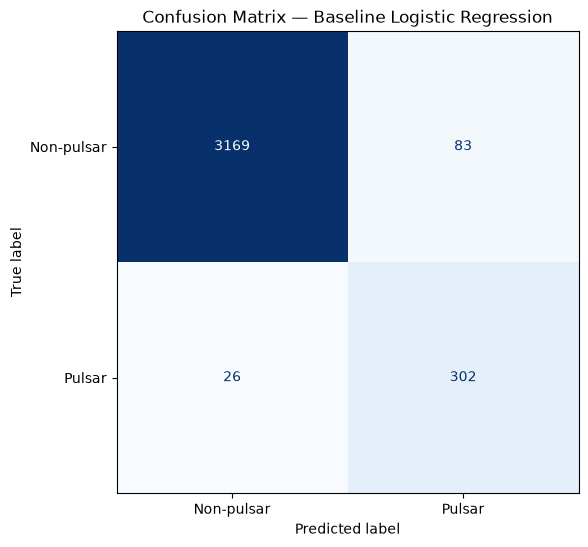

In [7]:
plot_confusion_matrix(y_true=y_test, y_pred=preds_logreg_pipeline, model_name="Baseline Logistic Regression")
plt.show()

### 3.1. Baseline Logistic Regression - Results

- Logistic Regression dramatically outperforms the Dummy baseline, confirming that the dataset contains strong linear separability out of the box.
- High `Recall` (92.07%) indicates the model successfully captures the vast majority of true pulsars at the default 0.5 threshold.
- `Precision` (78.44%) lags behind recall due to false positives, resulting in an $F_1$-score of 84.71%.
- While `ROC-AUC` (0.973) suggests near-perfect discrimination, it is overly optimistic here: the large pool of True Negatives (90.84%) inflates the denominator of FPR, masking the impact of False Positives.
- `PR-AUC (Average Precision)` (0.934) is the true indicator of ranking quality under imbalance: surging from the baseline prior of 0.0916 to 0.9337 demonstrates genuine predictive power on the minority class.
- -> Aligns with EDA: features derived from the integrated pulse profile (`kurtosis_profile`, `skewness_profile`, and `mean_profile`) provide strong linear separability between classes.
- -> Establishes a solid linear benchmark; subsequent non-linear models must beat this high bar, and threshold tuning can be used to optimize the precision-recall trade-off based on candidate verification costs.

## 4. Summary of Baseline Results

### 4.1. Dummy vs LogReg (Pivot Table)

In [8]:
baseline_results = [metrics_dummy, metrics_logreg]
df_baseline_results = pd.DataFrame(baseline_results)
df_baseline_results.sort_values(by="PR-AUC (AP)", ascending=False).round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC (AP)
1,Baseline Logistic Regression,0.9696,0.7844,0.9207,0.8471,0.9727,0.9337
0,Dummy,0.9084,0.0000,0.0000,0.0000,0.5000,0.0916


In [9]:
save_data(df_baseline_results, "docs/tables/baseline_metrics.csv")

### 4.2. Key Takeaways

- Metric Validation: Accuracy (~90.84% on Dummy) and ROC-AUC are heavily inflated by the dominant negative class (90.84%). PR-AUC (Average Precision) is the definitive metric for model ranking, establishing a theoretical floor at the class prior $P(Y=1) \approx 0.0916$.
- Strong Linear Baseline: Standardized Logistic Regression set a high benchmark (PR-AUC = 0.9337, Recall = 92.07%, $F_1$ = 84.71%), confirming EDA findings that pulse profile moments provide substantial linear separability.
- Precision Bottleneck: False positives cap precision at 78.44%. In radio astronomy surveys, candidate verification is expensive, making precision improvements and noise suppression critical.
- -> Next Steps (Feature Engineering):Apply power transforms (Yeo-Johnson) to correct heavy right skewness in DM-SNR features, and engineer dispersion ratios.
- -> Next Steps (Non-linear Models): Evaluate tree-based ensembles (Random Forest, LightGBM, XGBoost) to naturally handle bimodal splits in `kurtosis_dm_snr` and feature interactions.
- -> Next Steps (Decision Threshold Tuning): Optimize the classification threshold on validation PR-curves instead of relying on the default 0.5 to balance candidate inspection costs against missed pulsars.